# Medicine Usage, Side Effects, and Habit-Forming Drug Analysis

## Objective
This project explores a medicine dataset to analyze:
- common treatment categories
- frequent side effects
- habit-forming medicines
- therapeutic classes associated with habit formation

## Importing the Dependencies

In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [35]:
df = pd.read_csv("data/medicine_dataset.csv")
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (248218, 58)

Columns:
['id', 'name', 'substitute0', 'substitute1', 'substitute2', 'substitute3', 'substitute4', 'sideEffect0', 'sideEffect1', 'sideEffect2', 'sideEffect3', 'sideEffect4', 'sideEffect5', 'sideEffect6', 'sideEffect7', 'sideEffect8', 'sideEffect9', 'sideEffect10', 'sideEffect11', 'sideEffect12', 'sideEffect13', 'sideEffect14', 'sideEffect15', 'sideEffect16', 'sideEffect17', 'sideEffect18', 'sideEffect19', 'sideEffect20', 'sideEffect21', 'sideEffect22', 'sideEffect23', 'sideEffect24', 'sideEffect25', 'sideEffect26', 'sideEffect27', 'sideEffect28', 'sideEffect29', 'sideEffect30', 'sideEffect31', 'sideEffect32', 'sideEffect33', 'sideEffect34', 'sideEffect35', 'sideEffect36', 'sideEffect37', 'sideEffect38', 'sideEffect39', 'sideEffect40', 'sideEffect41', 'use0', 'use1', 'use2', 'use3', 'use4', 'Chemical Class', 'Habit Forming', 'Therapeutic Class', 'Action Class']


/tmp/ipykernel_1103/1096830822.py:1: DtypeWarning: Columns (42,43,44,45,46,47,48) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/medicine_dataset.csv")


## Dataset Overview
In this section, we inspect the dataset structure, columns, and missing values before starting the analysis.

In [36]:
df.head()

,id,name,substitute0,substitute1,substitute2,substitute3,substitute4,sideEffect0,sideEffect1,sideEffect2,...,sideEffect41,use0,use1,use2,use3,use4,Chemical Class,Habit Forming,Therapeutic Class,Action Class
0,1,augmentin 625 duo tablet,Penciclav 500 mg/125 mg Tablet,Moxikind-CV 625 Tablet,Moxiforce-CV 625 Tablet,Fightox 625 Tablet,Novamox CV 625mg Tablet,Vomiting,Nausea,Diarrhea,...,NaN,Treatment of Bacterial infections,NaN,NaN,NaN,NaN,NaN,No,ANTI INFECTIVES,NaN
1,2,azithral 500 tablet,Zithrocare 500mg Tablet,Azax 500 Tablet,Zady 500 Tablet,Cazithro 500mg Tablet,Trulimax 500mg Tablet,Vomiting,Nausea,Abdominal pain,...,NaN,Treatment of Bacterial infections,NaN,NaN,NaN,NaN,Macrolides,No,ANTI INFECTIVES,Macrolides
2,3,ascoril ls syrup,Solvin LS Syrup,Ambrodil-LX Syrup,Zerotuss XP Syrup,Capex LS Syrup,Broxum LS Syrup,Nausea,Vomiting,Diarrhea,...,NaN,Treatment of Cough with mucus,NaN,NaN,NaN,NaN,NaN,No,RESPIRATORY,NaN
3,4,allegra 120mg tablet,Lcfex Tablet,Etofex 120mg Tablet,Nexofex 120mg Tablet,Fexise 120mg Tablet,Histafree 120 Tablet,Headache,Drowsiness,Dizziness,...,NaN,Treatment of Sneezing and runny nose due to al...,Treatment of Allergic conditions,NaN,NaN,NaN,Diphenylmethane Derivative,No,RESPIRATORY,H1 Antihistaminics (second Generation)
4,5,avil 25 tablet,Eralet 25mg Tablet,NaN,NaN,NaN,NaN,Sleepiness,Dryness in mouth,NaN,...,NaN,Treatment of Allergic conditions,NaN,NaN,NaN,NaN,Pyridines Derivatives,No,RESPIRATORY,H1 Antihistaminics (First Generation)


### Basic Information
We first inspect the data types and non-null counts to understand the structure of the dataset.

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248218 entries, 0 to 248217
Data columns (total 58 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   id                 248218 non-null  int64 
 1   name               248218 non-null  object
 2   substitute0        238621 non-null  object
 3   substitute1        233867 non-null  object
 4   substitute2        230233 non-null  object
 5   substitute3        226856 non-null  object
 6   substitute4        223962 non-null  object
 7   sideEffect0        248218 non-null  object
 8   sideEffect1        238416 non-null  object
 9   sideEffect2        229500 non-null  object
 10  sideEffect3        207638 non-null  object
 11  sideEffect4        163560 non-null  object
 12  sideEffect5        131258 non-null  object
 13  sideEffect6        91857 non-null   object
 14  sideEffect7        67750 non-null   object
 15  sideEffect8        48506 non-null   object
 16  sideEffect9        3

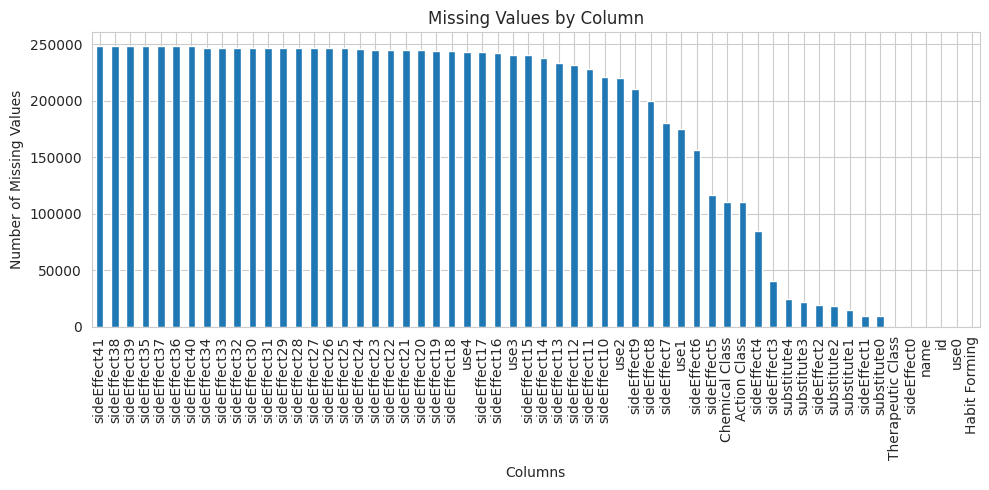

In [38]:
missing_counts = df.isna().sum().sort_values(ascending=False)

missing_counts.plot(kind='bar')
plt.title('Missing Values by Column')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.tight_layout()
plt.show()

In [39]:
threshold = len(df) * 0.05
print(f"5% missing-value threshold: {threshold:.0f} rows")

5% missing-value threshold: 12411 rows


In [40]:
cols_drop = df.columns[df.isna().sum() >= threshold]
print("Columns with >= 5% missing values:")
print(list(cols_drop))

Columns with >= 5% missing values:
['substitute1', 'substitute2', 'substitute3', 'substitute4', 'sideEffect2', 'sideEffect3', 'sideEffect4', 'sideEffect5', 'sideEffect6', 'sideEffect7', 'sideEffect8', 'sideEffect9', 'sideEffect10', 'sideEffect11', 'sideEffect12', 'sideEffect13', 'sideEffect14', 'sideEffect15', 'sideEffect16', 'sideEffect17', 'sideEffect18', 'sideEffect19', 'sideEffect20', 'sideEffect21', 'sideEffect22', 'sideEffect23', 'sideEffect24', 'sideEffect25', 'sideEffect26', 'sideEffect27', 'sideEffect28', 'sideEffect29', 'sideEffect30', 'sideEffect31', 'sideEffect32', 'sideEffect33', 'sideEffect34', 'sideEffect35', 'sideEffect36', 'sideEffect37', 'sideEffect38', 'sideEffect39', 'sideEffect40', 'sideEffect41', 'use1', 'use2', 'use3', 'use4', 'Chemical Class', 'Action Class']


In [41]:
cols_with_missingval = df.columns[df.isna().sum() < threshold]
print("Columns with < 5% missing values:")
print(list(cols_with_missingval))

Columns with < 5% missing values:
['id', 'name', 'substitute0', 'sideEffect0', 'sideEffect1', 'use0', 'Habit Forming', 'Therapeutic Class']


In [42]:
df['use0'] = df['use0'].fillna('Unknown')
df['sideEffect0'] = df['sideEffect0'].fillna('Unknown')
df['Habit Forming'] = df['Habit Forming'].fillna('Unknown')
df['Therapeutic Class'] = df['Therapeutic Class'].fillna('Unknown')

### Missing Value Observation
Columns with high missing-value rates should be treated carefully, since they may affect the reliability of the analysis.

In [43]:
print("Unique primary side effects:", df['sideEffect0'].nunique())

Unique primary side effects: 326


In [44]:
print("Unique medicine names:", df['name'].nunique())

Unique medicine names: 222825


In [45]:
print("Unique primary uses/treatments:", df['use0'].nunique())

Unique primary uses/treatments: 657


In [46]:
top_uses = df['use0'].value_counts(dropna=False).head(10)
print(top_uses)

use0
Treatment of Bacterial infections                             39573
 Pain relief                                                  22783
Treatment of Type 2 diabetes mellitus                         11350
 Bacterial infections                                         11288
Treatment of Gastroesophageal reflux disease (Acid reflux)     9749
Treatment of Hypertension (high blood pressure)                7632
Treatment of Sneezing and runny nose due to allergies          5104
Treatment of Heartburn                                         4079
Treatment of Neuropathic pain                                  4050
Treatment of Allergic conditions                               3878
Name: count, dtype: int64


### Observation
The most common treatment categories in the dataset include bacterial infections, pain relief, type 2 diabetes mellitus, and gastroesophageal reflux disease (acid reflux).

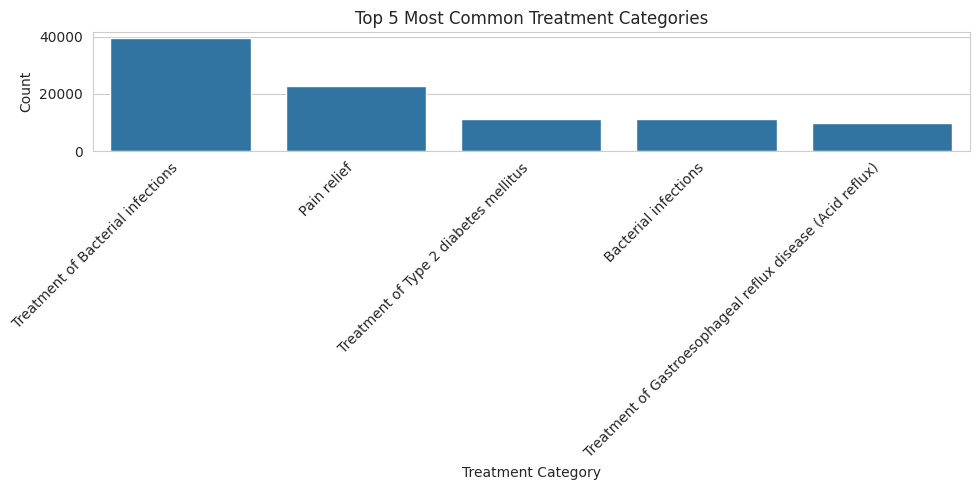

In [47]:
top_use_counts = df['use0'].value_counts().head(5)

sns.barplot(x=top_use_counts.index, y=top_use_counts.values)
plt.xlabel('Treatment Category')
plt.ylabel('Count')
plt.title('Top 5 Most Common Treatment Categories')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Insight
The treatment distribution is highly concentrated, with the top categories accounting for a large share of the dataset.

In [48]:
top5_share = df['use0'].value_counts(normalize=True).head(5).sum() * 100
print(f"Top 5 treatment categories account for {top5_share:.2f}% of the dataset.")

Top 5 treatment categories account for 38.17% of the dataset.


In [49]:
top_drug_names = df['name'].value_counts(dropna=False).head(10)
print(top_drug_names)

name
ns 0.9% infusion                     13
meditrax s 1000mg/500mg injection     8
luligee cream                         6
cefpoxim dry syrup                    6
mediceft 250mg injection              6
modace 100mg/500mg tablet             6
leflox 500mg tablet                   6
mucohelp 1gm injection                6
zocon l cream                         6
amrofast cream                        6
Name: count, dtype: int64


### Observation
A few medicine names appear multiple times in the dataset. For example, some drugs occur much more frequently than others, which may indicate repeated entries for common formulations or products.

In [50]:
top_side_effects = df["sideEffect0"].value_counts().head(10)
print(top_side_effects)

sideEffect0
Nausea                                                                   68477
Diarrhea                                                                 24253
Headache                                                                 16841
Vomiting                                                                 15031
Rash                                                                     11249
Dizziness                                                                 9434
Hypoglycemia (low blood glucose level)                                    7264
Sleepiness                                                                6949
Constipation                                                              6058
Application site reactions (burning, irritation, itching and redness)     5817
Name: count, dtype: int64


### Observation
The most frequent primary side effects are nausea, diarrhea, headache, vomiting, and rash.

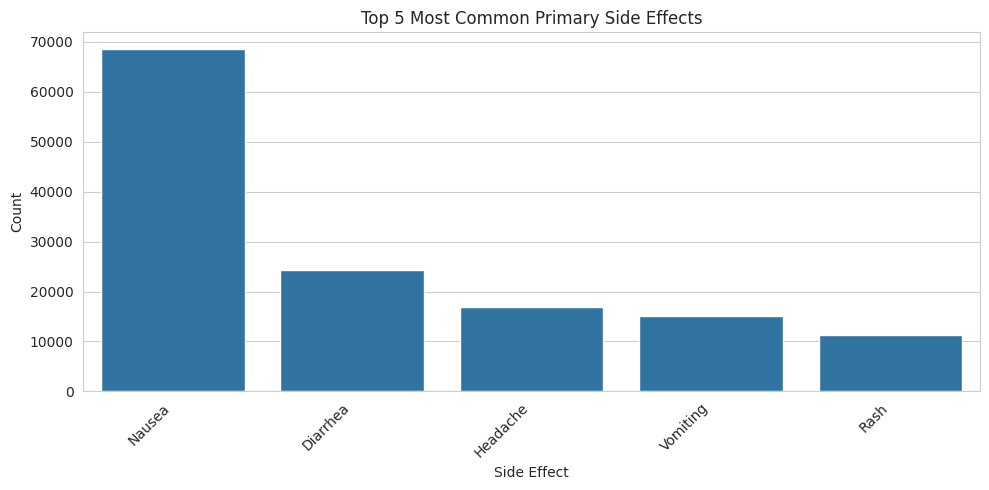

In [51]:
top_side_effect_counts = df['sideEffect0'].value_counts().head(5)

sns.barplot(x=top_side_effect_counts.index, y=top_side_effect_counts.values)
plt.xlabel('Side Effect')
plt.ylabel('Count')
plt.title('Top 5 Most Common Primary Side Effects')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Top treatment categories among habit-forming medicines:
use0
Treatment of Anxiety disorder      1546
 Moderate to severe pain            805
Treatment of Anxiety                707
 Pain relief                        365
Treatment of Insomnia               339
 Depression                         302
Treatment of Depression             252
Treatment of Short term anxiety     246
Treatment of Epilepsy/Seizures      223
 Dry cough                          198
Name: count, dtype: int64


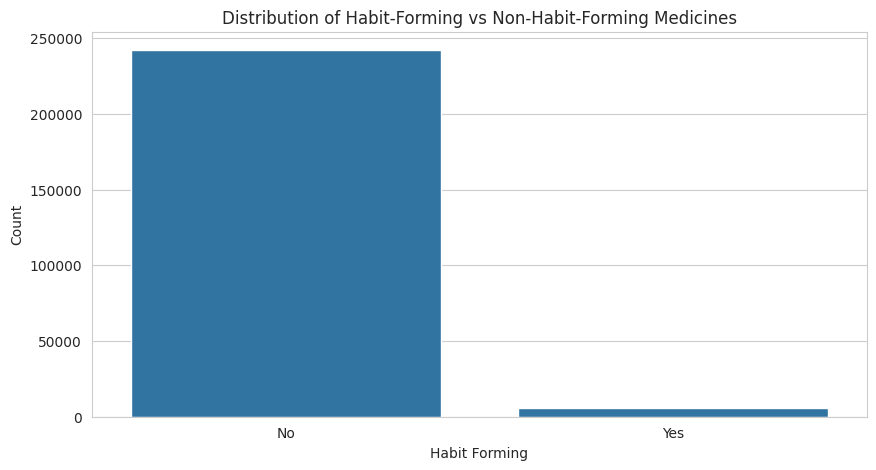

In [52]:
habit_forming = df[df["Habit Forming"] == "Yes"]

top_habit_uses = habit_forming['use0'].value_counts().head(10)
print("Top treatment categories among habit-forming medicines:")
print(top_habit_uses)

sns.countplot(x='Habit Forming', data=df)
plt.title('Distribution of Habit-Forming vs Non-Habit-Forming Medicines')
plt.xlabel('Habit Forming')
plt.ylabel('Count')
plt.show()

### Observation
Habit-forming medicines are most commonly associated with treatment areas such as anxiety, pain relief, and insomnia.

In [53]:
percentage = df['Habit Forming'].value_counts(normalize=True) * 100
print("Percentage distribution of habit-forming status:")
print(percentage)

Percentage distribution of habit-forming status:
Habit Forming
No     97.581561
Yes     2.418439
Name: proportion, dtype: float64


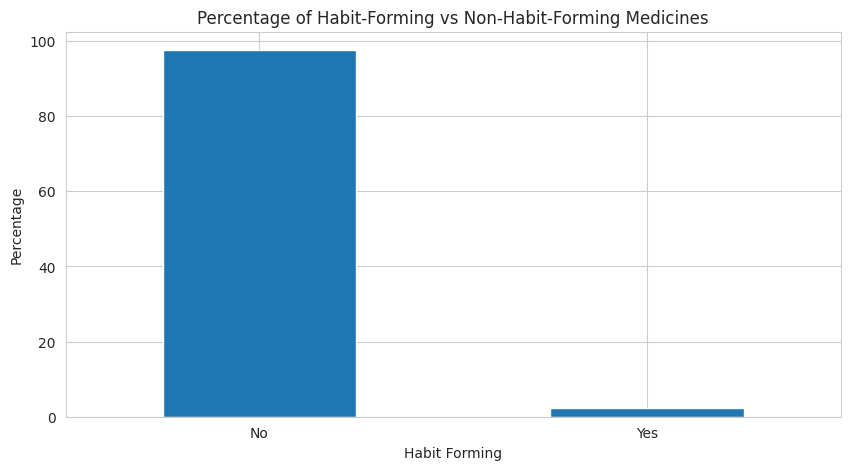

In [54]:
percentage.plot(kind='bar')
plt.title('Percentage of Habit-Forming vs Non-Habit-Forming Medicines')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.show()

### Insight
Only a small percentage of medicines in the dataset are labeled as habit-forming, while the vast majority are not.

Top therapeutic classes among habit-forming medicines:
Therapeutic Class
NEURO CNS            4054
PAIN ANALGESICS      1233
RESPIRATORY           474
GASTRO INTESTINAL     236
CARDIAC                 6
Name: count, dtype: int64


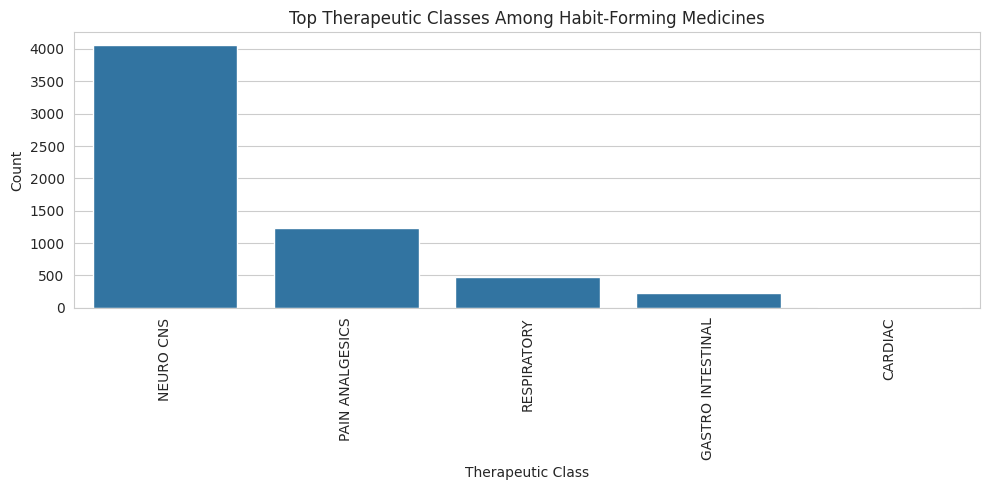

In [55]:
therapeutic_habit = (
    df[df["Habit Forming"] == "Yes"]["Therapeutic Class"]
    .value_counts()
    .head(10)
)

print("Top therapeutic classes among habit-forming medicines:")
print(therapeutic_habit)

sns.barplot(x=therapeutic_habit.index, y=therapeutic_habit.values)
plt.xlabel('Therapeutic Class')
plt.ylabel('Count')
plt.title('Top Therapeutic Classes Among Habit-Forming Medicines')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Observation
Among the therapeutic classes, Neuro/CNS-related medicines appear most frequently among habit-forming drugs in this dataset.

In [56]:
summary_table = pd.DataFrame({
    "Unique medicines": [df['name'].nunique()],
    "Unique treatments": [df['use0'].nunique()],
    "Unique side effects": [df['sideEffect0'].nunique()],
    "Habit-forming %": [df['Habit Forming'].value_counts(normalize=True).get('Yes', 0) * 100]
})

summary_table

,Unique medicines,Unique treatments,Unique side effects,Habit-forming %
0,222825,657,326,2.418439


## Final Summary

This analysis shows that:
- medicine usage is concentrated in a few treatment categories
- some side effects such as nausea and diarrhea appear much more frequently than others
- only a small portion of medicines are habit-forming
- habit-forming medicines are more common in classes related to anxiety, pain, insomnia, and Neuro/CNS treatments

## Limitations
- only the primary use (`use0`) and primary side effect (`sideEffect0`) were analyzed
- missing values may affect some conclusions
- this is an exploratory analysis and does not establish causal relationships